In [42]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import math
import random
from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      RandomForestClassifier as RFC,
      GradientBoostingRegressor as GBR,
      GradientBoostingClassifier as GBC)
from sklearn.preprocessing import LabelEncoder

Question 1

In [43]:
scores = [65, 70, 68, 73, 75, 80, 85, 78, 90, 100]

a.

In [44]:
mean = sum(scores) / len(scores)
mean

78.4

In [45]:
s = np.std(scores)
s

np.float64(10.229369482035537)

In [46]:
r = 2.262 * s / math.sqrt(len(scores))
print(mean - r)
print(mean + r)

71.08285828919516
85.71714171080485


The sample mean is 78.4, the standard deviation is 10.23, and the confidence interval is [71.08, 85.72].

b.

In [47]:
def bootstrap(data, n):
    means = []
    for j in range(n):
        indices = []
        bootstrap_sample = []
        for i in data:
            indices.append(random.randint(0,len(data)-1))
        for index in indices:
            bootstrap_sample.append(data[index])
        mean = sum(bootstrap_sample)/len(bootstrap_sample)
        means.append(mean)
    return means
    
means = bootstrap(scores, 40)
bootstrap_mean = sum(means) / len(means)
bootstrap_s = np.std(means)
bootstrap_r = 2.262 * bootstrap_s / math.sqrt(len(means))
print(f"The confidence interval is [{bootstrap_mean-bootstrap_r},{bootstrap_mean+bootstrap_r}]")

The confidence interval is [78.22668284881574,80.77331715118426]


c.

I would use the bootstrap method because the confidence interval that it gives is much smaller, so we can be more sure of what range the population mean is in

Question 2.

a.

In [48]:
np.random.shuffle(scores)
subsets = np.array_split(scores, 5)
subsets

[array([80, 65]),
 array([73, 68]),
 array([85, 70]),
 array([ 90, 100]),
 array([75, 78])]

b.

In [49]:
subset_means = []
for subset in subsets:
    mean = 0
    for score in scores:
        if score not in subset:
            mean += score
    mean = mean / 8
    subset_means.append(mean)
subset_means

[79.875, 80.375, 78.625, 74.25, 78.875]

c.

In [50]:
maes = []
for i in range(0, len(subset_means)):
    mae = 0.5*abs(subset_means[i] - (subsets[0][0] + subsets[0][1])/2)
    maes.append(mae)
maes

[np.float64(3.6875),
 np.float64(3.9375),
 np.float64(3.0625),
 np.float64(0.875),
 np.float64(3.1875)]

d.

In [51]:
avg_mae = sum(maes) / len(maes)
print(f'The average mean absolute error is {avg_mae}')

The average mean absolute error is 2.95


e.

In [52]:
new_mae = 0
mean = sum(scores) / len(scores)
for score in scores:
    new_mae += abs((score-mean))
new_mae = new_mae/len(scores)
new_mae

8.280000000000001

The mean absolute error on this "new" set would be 8.28.

Questions 3

In [53]:
OJ = load_data('OJ')
OJ

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.00,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.30,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.00,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.00,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.00,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,CH,252,7,1.86,2.09,0.10,0.00,0,0,0.587822,2.09,1.76,0.33,Yes,0.000000,0.053763,0.23,0
1066,CH,256,7,1.86,2.18,0.00,0.00,0,0,0.670258,2.18,1.86,0.32,Yes,0.000000,0.000000,0.32,0
1067,MM,257,7,1.86,2.18,0.00,0.00,0,0,0.736206,2.18,1.86,0.32,Yes,0.000000,0.000000,0.32,0
1068,CH,261,7,1.86,2.13,0.00,0.24,0,0,0.588965,1.89,1.86,0.03,Yes,0.112676,0.000000,0.27,0


a.

In [54]:
OJ['Store7'] = OJ['Store7'].replace({'Yes':1, 'No':0})
train, test = train_test_split(OJ,train_size=800,random_state=314)


C:\Users\kate\AppData\Local\Temp\ipykernel_5808\724269512.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  OJ['Store7'] = OJ['Store7'].replace({'Yes':1, 'No':0})
C:\Users\kate\AppData\Local\Temp\ipykernel_5808\724269512.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  OJ['Store7'] = OJ['Store7'].replace({'Yes':1, 'No':0})


b.

In [55]:
X_train = train[['WeekofPurchase', 'StoreID', 'PriceCH', 'PriceMM', 'DiscCH', 'DiscMM', 'SpecialCH', 'SpecialMM', 'LoyalCH','SalePriceMM','SalePriceCH','PriceDiff','Store7','PctDiscMM','PctDiscCH','ListPriceDiff','STORE']]
X_test = test[['WeekofPurchase', 'StoreID', 'PriceCH', 'PriceMM', 'DiscCH', 'DiscMM', 'SpecialCH', 'SpecialMM', 'LoyalCH','SalePriceMM','SalePriceCH','PriceDiff','Store7','PctDiscMM','PctDiscCH','ListPriceDiff','STORE']]
y_train = train[['Purchase']]
y_test = test[['Purchase']]

In [56]:
tree1 = DTC(max_leaf_nodes=6)
tree1.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,6
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
y_pred_train = tree1.predict(X_train)
conf_mat = confusion_matrix(y_train, y_pred_train)
print("Confusion Matrix:\n", conf_mat)

Confusion Matrix:
 [[445  43]
 [ 93 219]]


In [58]:
accuracy = accuracy_score(y_train, y_pred_train)
misclassification_error = 1 - accuracy
print(f"Training Accuracy: {accuracy:}")
print(f"Misclassification Error: {misclassification_error:}")

Training Accuracy: 0.83
Misclassification Error: 0.17000000000000004


c.

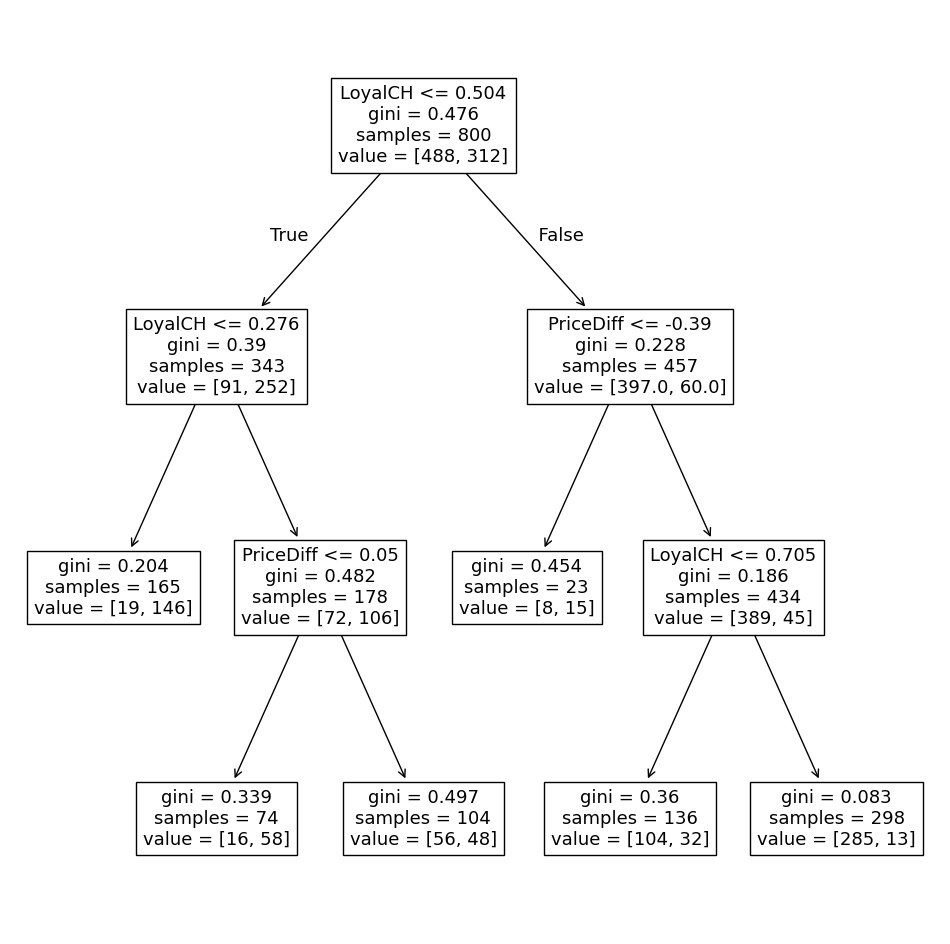

In [59]:
feature_names = list(X_train.columns)
ax = subplots(figsize=(12,12))[1]
plot_tree(tree1,
          feature_names=feature_names,
          ax=ax);

The first split is determined by loyalty to the CH brand. If the loyalty to CH is equal to or over 0.504, then you are more likely to purchase CH. The only other deciding feature on this tree is the price difference.

d.

In [60]:
y_pred_test = tree1.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:\n", conf_mat)

Confusion Matrix:
 [[147  18]
 [ 28  77]]


In [61]:
accuracy = accuracy_score(y_test, y_pred_test)
misclassification_error = 1 - accuracy
print(f"Prediction Accuracy: {accuracy:}")
print(f"Misclassification Error: {misclassification_error:}")

Prediction Accuracy: 0.8296296296296296
Misclassification Error: 0.1703703703703704


e.

In [62]:
tree2 = DTC(max_leaf_nodes=8)
tree2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,8
,min_impurity_decrease,0.0
,class_weight,None


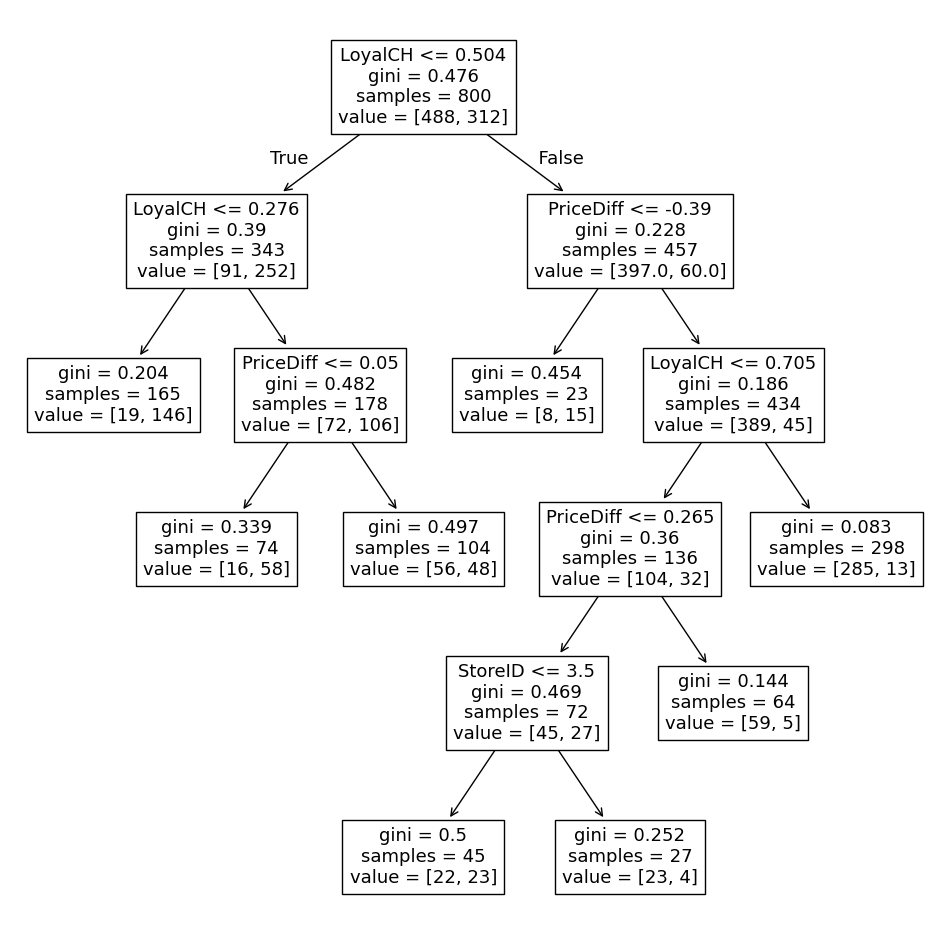

In [63]:
feature_names = list(X_train.columns)
ax = subplots(figsize=(12,12))[1]
plot_tree(tree2,
          feature_names=feature_names,
          ax=ax);

In [64]:
y_pred_test2 = tree2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test2)
misclassification_error = 1 - accuracy
print(f"Prediction Accuracy: {accuracy:}")
print(f"Misclassification Error: {misclassification_error:}")

Prediction Accuracy: 0.8185185185185185
Misclassification Error: 0.18148148148148147


The test error increased.

f. The new model is overfit because the test error increased when I used the 8 maximum leaf nodes instead of the 6 maximum leaf nodes.

g.

In [65]:
clf = DTC(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

cv_scores = []
for alpha in ccp_alphas:
    tree = DTC(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())


best_alpha = ccp_alphas[np.argmax(cv_scores)]


optimal_tree = DTC(random_state=42, ccp_alpha=best_alpha)
optimal_tree.fit(X_train, y_train)

test_accuracy = optimal_tree.score(X_test, y_test)
test_error = 1 - test_accuracy
print(f"Test misclassification error with optimal leaf nodes: {test_error:.3f}")

print("Number of leaf nodes in optimal tree:", optimal_tree.get_n_leaves())

Test misclassification error with optimal leaf nodes: 0.170
Number of leaf nodes in optimal tree: 5


The optimal number of leaf nodes is 5.

In [66]:
tree3 = DTC(max_leaf_nodes=5)
tree3.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,5
,min_impurity_decrease,0.0
,class_weight,None


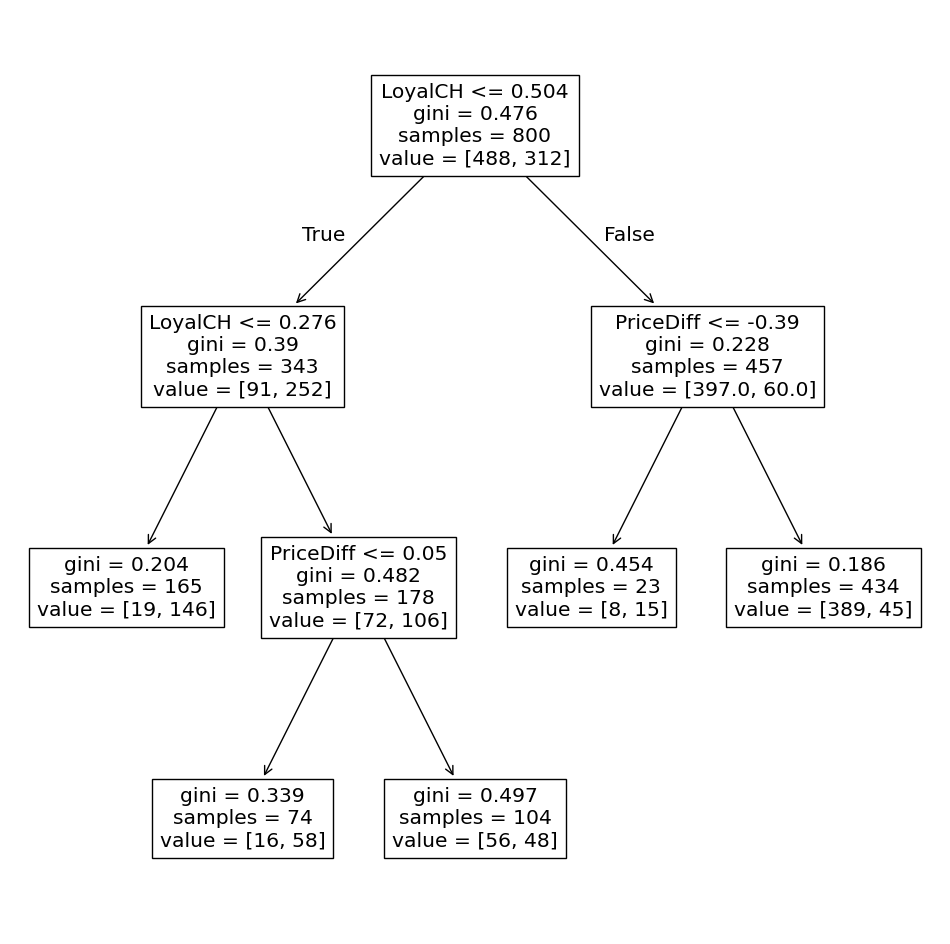

In [67]:
feature_names = list(X_train.columns)
ax = subplots(figsize=(12,12))[1]
plot_tree(tree3,
          feature_names=feature_names,
          ax=ax);

In [68]:
y_pred_test3 = tree3.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test3)
misclassification_error = 1 - accuracy
print(f"Prediction Accuracy: {accuracy:}")
print(f"Misclassification Error: {misclassification_error:}")

Prediction Accuracy: 0.8296296296296296
Misclassification Error: 0.1703703703703704


The total misclassification error decreases from the tree with maximum 8 leafs but it is the same as the tree with maximum 6 leafs.

h.

In [69]:
rf = RFC(max_features=6,
             n_estimators=1000,
             max_leaf_nodes=5,
             random_state=314)
rf.fit(X_train, y_train)


c:\Users\kate\anaconda3\envs\islp\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,1000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,5
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_rf_test_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_rf_test_pred)
misclassification_error = 1 - accuracy
print(f"Prediction Accuracy: {accuracy:}")
print(f"Misclassification Error: {misclassification_error:}")

Prediction Accuracy: 0.8037037037037037
Misclassification Error: 0.1962962962962963


My initial hyperparameter are max_features=6, n_estimators=1000, max_leaf_nodes=5, and random_state=314. The misclassification error is 0.196.

i.

In [71]:
rf2 = RFC(max_features=6,
             n_estimators=250,
             max_depth=5,
             max_leaf_nodes=10,
             min_samples_leaf = 20,
             random_state=314)
rf2.fit(X_train, y_train)

y_rf_test_pred2 = rf2.predict(X_test)
accuracy = accuracy_score(y_test, y_rf_test_pred2)
misclassification_error = 1 - accuracy
print(f"Prediction Accuracy: {accuracy:}")
print(f"Misclassification Error: {misclassification_error:}")

c:\Users\kate\anaconda3\envs\islp\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Prediction Accuracy: 0.8185185185185185
Misclassification Error: 0.18148148148148147


My final chosen hyperparameters are max_features=6, n_estimators=250, max_depth=5, max_leaf_nodes=10, min_samples_leaf=20, and random_state = 314. The missclassification error is 0.181. 

k.

In [72]:
gbm = GBC(learning_rate=0.2,
               n_estimators=50,
               max_depth=5,
               random_state=314)
gbm.fit(X_train, y_train)

c:\Users\kate\anaconda3\envs\islp\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'log_loss'
,learning_rate,0.2
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [73]:
y_gbm_test_pred = gbm.predict(X_test)
accuracy = accuracy_score(y_test, y_gbm_test_pred)
misclassification_error = 1 - accuracy
print(f"Prediction Accuracy: {accuracy:}")
print(f"Misclassification Error: {misclassification_error:}")

Prediction Accuracy: 0.7888888888888889
Misclassification Error: 0.21111111111111114


My intiial hyperparameters are learning_rate=0.2, n_estimators=50, max_depth=5, and random_state=314. The misclassification rate is 0.211.

l.

In [74]:
gbm2 = GBC(learning_rate=0.01,
            min_samples_leaf=4,
               n_estimators=200,
               max_depth=5,
               min_samples_split=10,
               random_state=314)
gbm2.fit(X_train, y_train)
y_gbm_test_pred2 = gbm2.predict(X_test)
accuracy = accuracy_score(y_test, y_gbm_test_pred2)
misclassification_error = 1 - accuracy
print(f"Prediction Accuracy: {accuracy:}")
print(f"Misclassification Error: {misclassification_error:}")

c:\Users\kate\anaconda3\envs\islp\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Prediction Accuracy: 0.8222222222222222
Misclassification Error: 0.1777777777777778


My final chosen hyperparameters are learning_rate=0.01, min_samples_leaf=4, n_estimators=200, max_depth=5, min_samples_split=10, and random_state=314. The missclassification rate is 0.178.

m.

In [75]:
def plot_classification_lift_chart(y_true, y_prob_model1, y_prob_model2,
                                   model1_name='Model A', model2_name='Model B',
                                   n_bins=10):

    # Ensure numeric and in DataFrame
    data = pd.DataFrame({
        'y_true': np.ravel(y_true),
        'pred1': np.ravel(y_prob_model1),
        'pred2': np.ravel(y_prob_model2)
    })

    # Sort descending by each model’s probability
    data1 = data.sort_values('pred1', ascending=False)
    data2 = data.sort_values('pred2', ascending=False)

    # Bin by quantiles
    data1['bin'] = pd.qcut(data1['pred1'], n_bins, labels=False, duplicates='drop')
    data2['bin'] = pd.qcut(data2['pred2'], n_bins, labels=False, duplicates='drop')

    # Compute actual response rate (lift)
    lift1 = data1.groupby('bin')['y_true'].mean() / data['y_true'].mean()
    lift2 = data2.groupby('bin')['y_true'].mean() / data['y_true'].mean()

    plt.figure(figsize=(8,5))
    plt.plot(lift1.index, lift1, marker='o', label=f'{model1_name} Lift')
    plt.plot(lift2.index, lift2, marker='s', label=f'{model2_name} Lift')
    plt.axhline(1, color='red', linestyle='--', label='Baseline')
    plt.title('Classification Lift Chart')
    plt.xlabel('Probability Bin (Quantiles)')
    plt.ylabel('Lift over Baseline')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


In [76]:


le = LabelEncoder()

# Fit on y_true (training or test)
y_test_num = le.fit_transform(y_test)           # Converts 'CH'->1, 'MM'->0 (for example)
y_rf_prob = rf2.predict_proba(X_test)[:, 1]   # Probability of positive class
y_gbm_prob = gbm2.predict_proba(X_test)[:, 1]

# Now y_test_num is numeric, and y_rf_prob / y_gbm_prob are numeric probabilities


c:\Users\kate\anaconda3\envs\islp\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


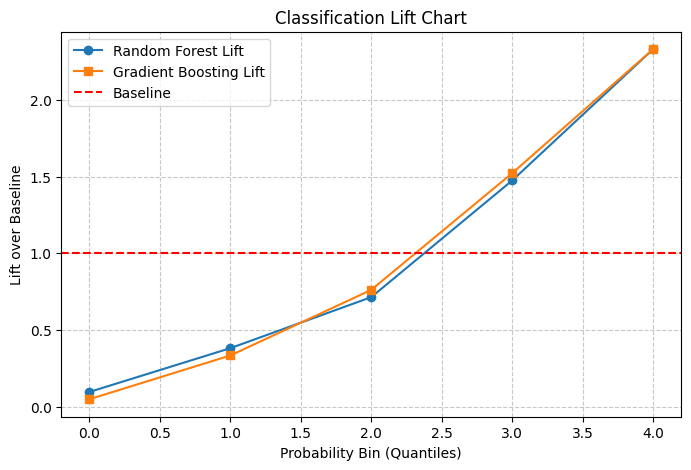

In [77]:
plot_classification_lift_chart(y_test_num, y_rf_prob, y_gbm_prob,
                               model1_name='Random Forest',
                               model2_name='Gradient Boosting',
                               n_bins=5)



The misclassification rate for both models were very close, it so makes sense that their lift charts are also close to each other. There is no clear model which better segments the data.